# Data Science Project- Finance 

## Project Title
### Domain: Finance
**Title:** Utilizing Machine Learning to Forecast the Probability of Successfully Collecting Debts by Analyzing Statute-Barred Status

### Problem Statement
In debt collection, identifying accounts that are statute-barred is critical since such debts may no longer be legally enforceable. This project aims to build a sophisticated machine-learning model that predicts the probability of successful debt recovery, focusing on the IsStatBarred field (Y status) as the target variable for classification. Using a dataset with 406,424 rows and 22 columns of debtor and account details, this model seeks to optimize resource allocation by prioritizing accounts likely to yield successful recovery.

### Data Overview
##### Key Attributes
**EntityID:** Unique identifier for each entry.
**OriginalCreditor:** Name of the original creditor (redacted for privacy).
**AccountID:** Unique identifier for the account.
**CurrentBalance:** Current balance on the account.
**DebtLoadPrincipal:** Original debt amount at the time of load.
**BalanceAtDebtLoad:** Account balance at the time of debt load.
**PurchasePrice:** Purchase price of the debt.
**ProductOrDebtType:** Type/category of debt or product.
**CollectionStatus:** Status of the collection process.
**CloseDate:** Date when the account was closed.
**ClosureReason:** Reason for account closure.
**InBankruptcy:** Whether the account is involved in bankruptcy.
**AccountInsolvencyType:** Type of insolvency associated with the account.
**CustomerInsolvencyType:** Insolvency type for the customer.
**IsLegal:** Indicates if legal action has been initiated.
**InterestRate:** Interest rate on the debt.
**LastPaymentAmount:** Amount of the most recent payment.
**LastPaymentMethod:** Method used for the last payment.
**NumLiableParties:** Number of liable parties associated with the account.
**CustomerAge:** Age of the customer.
NumPhones, NumEmails, NumAddresses: Number of contact points for the customer.
**IsStatBarred:** Indicates if the account is statute-barred (Target Variable).


# Proposed Solution
**Objective**:Build a machine learning model that:

Predicts the probability of debt recovery by analyzing whether an account is statute-barred (IsStatBarred = Y).
Prioritizes accounts with a higher likelihood of recovery for collection efforts.
Identifies key factors influencing statute-barred status and recovery probabilities.


In [201]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [203]:
# Loading the Dataset

In [205]:
df = pd.read_excel("/Users/edith/Downloads/Company_x.xlsx")

In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406423 entries, 0 to 406422
Data columns (total 25 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   EntityID                    406423 non-null  int64  
 1   OriginalCreditor[Redacted]  406423 non-null  object 
 2   AccountID                   406423 non-null  int64  
 3   CurrentBalance              406423 non-null  float64
 4   DebtLoadPrincipal           406423 non-null  float64
 5   Balanaceatdebt_load         406423 non-null  float64
 6   PurchasePrice               403731 non-null  float64
 7   ProductOrDebtType           406423 non-null  object 
 8   CollectionStatus            406423 non-null  object 
 9   ClosureReason               9030 non-null    object 
 10  InBankruptcy                406423 non-null  object 
 11  AccountInsolvencyType       285 non-null     object 
 12  CustomerInsolvencyType      8531 non-null    object 
 13  IsLegal       

In [207]:
df.head()

,EntityID,OriginalCreditor[Redacted],AccountID,CurrentBalance,DebtLoadPrincipal,Balanaceatdebt_load,PurchasePrice,ProductOrDebtType,CollectionStatus,ClosureReason,...,LastPaymentMethod,NumLiableParties,CustomerAge,NumPhones,NumEmails,NumAddresses,IsStatBarred,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,932,Creditor 1,3677,0.0,1160.20,1160.20,4.22,Other,PAID_IN_FULL,NaN,...,Cheque,1.0,53.0,0,0,1,N,NaN,NaN,NaN
1,160,Creditor 2,4276,182.9,182.90,182.90,4.22,Other,CANCELLED_WITHDRAWN,NaN,...,NaN,1.0,NaN,0,0,1,Y,NaN,NaN,NaN
2,932,Creditor 1,8525,0.0,538.57,538.57,4.22,Other,PAID_IN_FULL,NaN,...,Cheque,1.0,NaN,1,0,1,N,NaN,NaN,NaN
3,160,Creditor 2,9859,8279.5,8279.50,8279.50,4.22,Other,PASSIVE,NaN,...,NaN,1.0,NaN,1,0,1,Y,NaN,NaN,NaN
4,932,Creditor 1,12807,0.0,523.00,523.00,4.22,Other,PAID_IN_FULL,NaN,...,Cheque,1.0,46.0,2,0,1,Y,NaN,NaN,NaN


In [208]:
df.shape

(406423, 25)

In [17]:
df.columns

Index(['EntityID', 'OriginalCreditor[Redacted]', 'AccountID', 'CurrentBalance',
       'DebtLoadPrincipal', 'Balanaceatdebt_load', 'PurchasePrice',
       'ProductOrDebtType', 'CollectionStatus', 'ClosureReason',
       'InBankruptcy', 'AccountInsolvencyType', 'CustomerInsolvencyType',
       'IsLegal', 'LastPaymentAmount', 'LastPaymentMethod', 'NumLiableParties',
       'CustomerAge', 'NumPhones', 'NumEmails', 'NumAddresses', 'IsStatBarred',
       'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24'],
      dtype='object')

In [19]:
df.columns.str.strip()

Index(['EntityID', 'OriginalCreditor[Redacted]', 'AccountID', 'CurrentBalance',
       'DebtLoadPrincipal', 'Balanaceatdebt_load', 'PurchasePrice',
       'ProductOrDebtType', 'CollectionStatus', 'ClosureReason',
       'InBankruptcy', 'AccountInsolvencyType', 'CustomerInsolvencyType',
       'IsLegal', 'LastPaymentAmount', 'LastPaymentMethod', 'NumLiableParties',
       'CustomerAge', 'NumPhones', 'NumEmails', 'NumAddresses', 'IsStatBarred',
       'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24'],
      dtype='object')

In [213]:
df.dtypes

EntityID                        int64
OriginalCreditor[Redacted]     object
AccountID                       int64
CurrentBalance                float64
DebtLoadPrincipal             float64
Balanaceatdebt_load           float64
PurchasePrice                 float64
ProductOrDebtType              object
CollectionStatus               object
ClosureReason                  object
InBankruptcy                   object
AccountInsolvencyType          object
CustomerInsolvencyType         object
IsLegal                        object
LastPaymentAmount             float64
LastPaymentMethod              object
NumLiableParties              float64
CustomerAge                   float64
NumPhones                       int64
NumEmails                       int64
NumAddresses                    int64
IsStatBarred                   object
Unnamed: 22                   float64
Unnamed: 23                   float64
Unnamed: 24                   float64
dtype: object

In [215]:
df['IsStatBarred'].value_counts(normalize=True)

IsStatBarred
Y    0.700128
N    0.299872
Name: proportion, dtype: float64

In [217]:
df.duplicated().sum()

0

In [219]:
df.isnull().sum()

EntityID                           0
OriginalCreditor[Redacted]         0
AccountID                          0
CurrentBalance                     0
DebtLoadPrincipal                  0
Balanaceatdebt_load                0
PurchasePrice                   2692
ProductOrDebtType                  0
CollectionStatus                   0
ClosureReason                 397393
InBankruptcy                       0
AccountInsolvencyType         406138
CustomerInsolvencyType        397892
IsLegal                            0
LastPaymentAmount             302446
LastPaymentMethod             302446
NumLiableParties                 122
CustomerAge                    29482
NumPhones                          0
NumEmails                          0
NumAddresses                       0
IsStatBarred                       0
Unnamed: 22                   406423
Unnamed: 23                   406423
Unnamed: 24                   406422
dtype: int64

In [221]:
# Handling the missing values
imputer = SimpleImputer(strategy='most_frequent')
data = df.apply(lambda x: imputer.fit_transform(x.values.reshape(-1, 1)).flatten() if x.isnull().any() else x)

In [223]:
# Classify columns into numerical and categorical
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical Columns:", numerical_columns)
print("Categorical Columns:", categorical_columns)


Numerical Columns: ['EntityID', 'AccountID', 'CurrentBalance', 'DebtLoadPrincipal', 'Balanaceatdebt_load', 'PurchasePrice', 'LastPaymentAmount', 'NumLiableParties', 'CustomerAge', 'NumPhones', 'NumEmails', 'NumAddresses', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24']
Categorical Columns: ['OriginalCreditor[Redacted]', 'ProductOrDebtType', 'CollectionStatus', 'ClosureReason', 'InBankruptcy', 'AccountInsolvencyType', 'CustomerInsolvencyType', 'IsLegal', 'LastPaymentMethod', 'IsStatBarred']


In [225]:
# Step 2: Encode categorical variables (if needed)
label_encoder = LabelEncoder()

categorical_columns = [
    'OriginalCreditor[Redacted]', 'ProductOrDebtType', 'CollectionStatus', 'ClosureReason', 
    'AccountInsolvencyType', 'CustomerInsolvencyType', 'LastPaymentMethod', 'IsLegal', 
    'IsStatBarred'
]
# Encode the columns if they exist in the DataFrame
for col in categorical_columns:
    if col in data.columns:
        data[col] = label_encoder.fit_transform(data[col])
    else:
        print(f"Warning: Column '{col}' not found in the DataFrame.")

AttributeError: 'Series' object has no attribute 'columns'

In [227]:
df.columns

Index(['EntityID', 'OriginalCreditor[Redacted]', 'AccountID', 'CurrentBalance',
       'DebtLoadPrincipal', 'Balanaceatdebt_load', 'PurchasePrice',
       'ProductOrDebtType', 'CollectionStatus', 'ClosureReason',
       'InBankruptcy', 'AccountInsolvencyType', 'CustomerInsolvencyType',
       'IsLegal', 'LastPaymentAmount', 'LastPaymentMethod', 'NumLiableParties',
       'CustomerAge', 'NumPhones', 'NumEmails', 'NumAddresses', 'IsStatBarred',
       'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24'],
      dtype='object')

# Data Pre-processing and Cleaning

As we are having difficulty with data that is clearly visible some unnamed column with empty values are there. We need to clean data carefully.

## Preserving Non-NaN Columns
To resolve this:

a) Identify and drop columns where all values are NaN before applying the SimpleImputer.
b) Apply the imputer only to the remaining columns, ensuring the DataFrame structure is preserved.

## Key Fixes:

1. Dropping Empty Columns:

Columns Unnamed: 22, Unnamed: 23, and Unnamed: 24 are completely empty, so they are dropped using dropna(axis=1, how='all').

2. Column Mismatch:

The SimpleImputer no longer removes columns since the fully NaN ones are already handled.

3. Data Types Restoration:

Restored original data types after imputation to maintain consistency.

4. Encoding:

Handled categorical encoding robustly by ensuring all columns exist and converting non-string values to string before encoding.


In [230]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406423 entries, 0 to 406422
Data columns (total 25 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   EntityID                    406423 non-null  int64  
 1   OriginalCreditor[Redacted]  406423 non-null  object 
 2   AccountID                   406423 non-null  int64  
 3   CurrentBalance              406423 non-null  float64
 4   DebtLoadPrincipal           406423 non-null  float64
 5   Balanaceatdebt_load         406423 non-null  float64
 6   PurchasePrice               403731 non-null  float64
 7   ProductOrDebtType           406423 non-null  object 
 8   CollectionStatus            406423 non-null  object 
 9   ClosureReason               9030 non-null    object 
 10  InBankruptcy                406423 non-null  object 
 11  AccountInsolvencyType       285 non-null     object 
 12  CustomerInsolvencyType      8531 non-null    object 
 13  IsLegal       

In [232]:
df.shape

(406423, 25)

In [234]:
df.columns

Index(['EntityID', 'OriginalCreditor[Redacted]', 'AccountID', 'CurrentBalance',
       'DebtLoadPrincipal', 'Balanaceatdebt_load', 'PurchasePrice',
       'ProductOrDebtType', 'CollectionStatus', 'ClosureReason',
       'InBankruptcy', 'AccountInsolvencyType', 'CustomerInsolvencyType',
       'IsLegal', 'LastPaymentAmount', 'LastPaymentMethod', 'NumLiableParties',
       'CustomerAge', 'NumPhones', 'NumEmails', 'NumAddresses', 'IsStatBarred',
       'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24'],
      dtype='object')

In [236]:
# Cleaning of column names
df.columns = df.columns.str.strip()  # Remove any leading/trailing whitespace in column names

In [238]:
df.columns

Index(['EntityID', 'OriginalCreditor[Redacted]', 'AccountID', 'CurrentBalance',
       'DebtLoadPrincipal', 'Balanaceatdebt_load', 'PurchasePrice',
       'ProductOrDebtType', 'CollectionStatus', 'ClosureReason',
       'InBankruptcy', 'AccountInsolvencyType', 'CustomerInsolvencyType',
       'IsLegal', 'LastPaymentAmount', 'LastPaymentMethod', 'NumLiableParties',
       'CustomerAge', 'NumPhones', 'NumEmails', 'NumAddresses', 'IsStatBarred',
       'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24'],
      dtype='object')

In [240]:
# Drop columns where all values are NaN
df = df.dropna(axis=1, how='all')

In [242]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicates)


Number of duplicate rows: 0


In [244]:
# Check for missing values
missing_values = df.isnull().sum()
print("\nMissing Values Per Column:")
print(missing_values)


Missing Values Per Column:
EntityID                           0
OriginalCreditor[Redacted]         0
AccountID                          0
CurrentBalance                     0
DebtLoadPrincipal                  0
Balanaceatdebt_load                0
PurchasePrice                   2692
ProductOrDebtType                  0
CollectionStatus                   0
ClosureReason                 397393
InBankruptcy                       0
AccountInsolvencyType         406138
CustomerInsolvencyType        397892
IsLegal                            0
LastPaymentAmount             302446
LastPaymentMethod             302446
NumLiableParties                 122
CustomerAge                    29482
NumPhones                          0
NumEmails                          0
NumAddresses                       0
IsStatBarred                       0
Unnamed: 24                   406422
dtype: int64


In [246]:
# Importing pre-processing and encoding libraries

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer


# Use SimpleImputer to impute missing values with the most frequent value in each column
imputer = SimpleImputer(strategy='most_frequent')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Convert data types back to original types for clarity
for col in df.columns:
    if df[col].dtype == 'int64':
        df_imputed[col] = df_imputed[col].astype(int)
    elif df[col].dtype == 'float64':
        df_imputed[col] = df_imputed[col].astype(float)

In [247]:
# Classify columns into numerical and categorical
numerical_columns = df_imputed.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = df_imputed.select_dtypes(include=['object', 'category']).columns.tolist()

print("\nNumerical Columns:", numerical_columns)
print("\nCategorical Columns:", categorical_columns)


Numerical Columns: ['EntityID', 'AccountID', 'CurrentBalance', 'DebtLoadPrincipal', 'Balanaceatdebt_load', 'PurchasePrice', 'LastPaymentAmount', 'NumLiableParties', 'CustomerAge', 'NumPhones', 'NumEmails', 'NumAddresses', 'Unnamed: 24']

Categorical Columns: ['OriginalCreditor[Redacted]', 'ProductOrDebtType', 'CollectionStatus', 'ClosureReason', 'InBankruptcy', 'AccountInsolvencyType', 'CustomerInsolvencyType', 'IsLegal', 'LastPaymentMethod', 'IsStatBarred']


In [250]:
# Encode categorical variables
label_encoder = LabelEncoder()

# Define specific categorical columns for encoding
columns_to_encode = [
    'OriginalCreditor[Redacted]', 'ProductOrDebtType', 'CollectionStatus', 'ClosureReason',
    'AccountInsolvencyType', 'CustomerInsolvencyType', 'LastPaymentMethod', 'IsLegal', 'IsStatBarred'
]

# Check and encode only columns present in the DataFrame
for col in columns_to_encode:
    if col in df_imputed.columns:
        df_imputed[col] = label_encoder.fit_transform(df_imputed[col].astype(str))  # Handle non-string values
    else:
        print(f"Warning: Column '{col}' not found in the DataFrame.")


In [252]:
# Validate the processed DataFrame
print("\nProcessed Dataset Preview:")
print(df_imputed.head())


Processed Dataset Preview:
   EntityID  OriginalCreditor[Redacted]  AccountID  CurrentBalance  \
0       932                           0       3677             0.0   
1       160                          11       4276           182.9   
2       932                           0       8525             0.0   
3       160                          11       9859          8279.5   
4       932                           0      12807             0.0   

   DebtLoadPrincipal  Balanaceatdebt_load  PurchasePrice  ProductOrDebtType  \
0            1160.20              1160.20           4.22                  5   
1             182.90               182.90           4.22                  5   
2             538.57               538.57           4.22                  5   
3            8279.50              8279.50           4.22                  5   
4             523.00               523.00           4.22                  5   

   CollectionStatus  ClosureReason  ... IsLegal  LastPaymentAmount  \
0     

In [254]:
# Final check for missing values
print("\nMissing Values After Processing:")
print(df_imputed.isnull().sum())


Missing Values After Processing:
EntityID                      0
OriginalCreditor[Redacted]    0
AccountID                     0
CurrentBalance                0
DebtLoadPrincipal             0
Balanaceatdebt_load           0
PurchasePrice                 0
ProductOrDebtType             0
CollectionStatus              0
ClosureReason                 0
InBankruptcy                  0
AccountInsolvencyType         0
CustomerInsolvencyType        0
IsLegal                       0
LastPaymentAmount             0
LastPaymentMethod             0
NumLiableParties              0
CustomerAge                   0
NumPhones                     0
NumEmails                     0
NumAddresses                  0
IsStatBarred                  0
Unnamed: 24                   0
dtype: int64


# Key Features in dataset:

## Account Details
    CurrentBalance, DebtLoadPrincipal, BalanceAtDebtLoad: Financial health of the account.

## InterestRate: Potential profitability.
    ProductOrDebtType: Patterns in debt type affecting recoverability.

##  Debtor Details
    CustomerAge, NumPhones, NumEmails, NumAddresses: Communication readiness.
    InBankruptcy, AccountInsolvencyType, CustomerInsolvencyType: Legal complexities.

## Collection and Payment History
    LastPaymentAmount, LastPaymentMethod: Debtor’s payment trends.
    CollectionStatus, IsLegal: Collection actions’ influence on outcomes.
    
## Statute-Barred Indicators

    CloseDate, IsStatBarred: Legal enforceability window.

In [257]:
# Classification of key features and its analysis:
key_features = [
    "Current Balance", "DebtLoadPrincipal", "BalanceAtDebtLoad", "PurchasePrice", 
    "ProductOrDebtType", "CollectionStatus", "IsStatBarred"
]


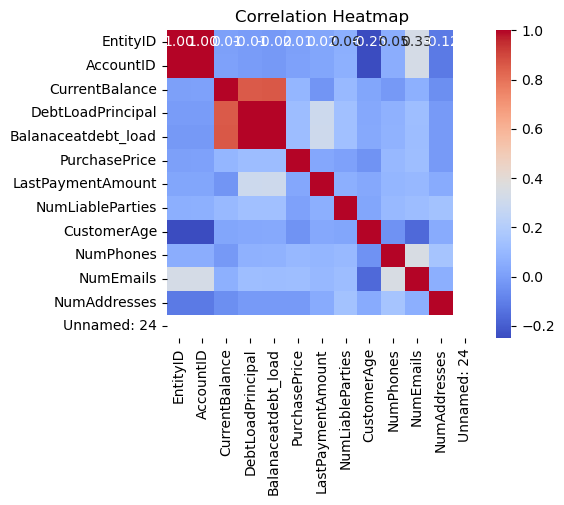

In [259]:
# Correlation heatmap for numerical features
numerical_features = df.select_dtypes(include=["float64", "int64"])
if not numerical_features.empty:
    plt.figure(figsize=(5, 4))
    sns.heatmap(numerical_features.corr(), annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()
else:
    print("No numerical features available for correlation analysis.")

# Insight: High correlation values suggest relationships (e.g., PurchasePrice might relate to DebtLoadPrincipal).

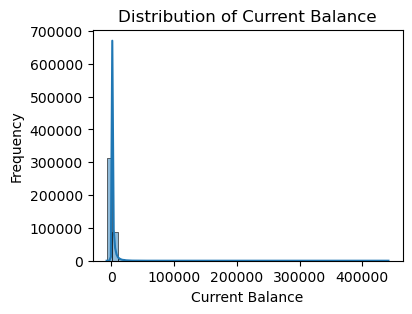

In [261]:
# Distribution of Current Balance
if "CurrentBalance" in df.columns:
    plt.figure(figsize=(4, 3))
    sns.histplot(df["CurrentBalance"].dropna(), bins=50, kde=True)
    plt.title("Distribution of Current Balance")
    plt.xlabel("Current Balance")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("Current Balance column is not present in the dataset.")

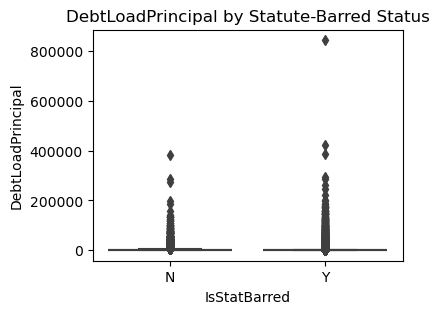

In [263]:
# Boxplot for DebtLoadPrincipal by IsStatBarred
if "DebtLoadPrincipal" in df.columns and "IsStatBarred" in df.columns:
    plt.figure(figsize=(4, 3))
    sns.boxplot(x="IsStatBarred", y="DebtLoadPrincipal", data=df)
    plt.title("DebtLoadPrincipal by Statute-Barred Status")
    plt.xlabel("IsStatBarred")
    plt.ylabel("DebtLoadPrincipal")
    plt.show()
else:
    print("Required columns for boxplot are not present in the dataset.")


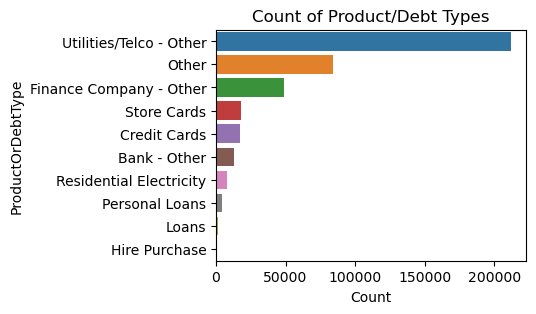

In [265]:
# Count plot for ProductOrDebtType
if "ProductOrDebtType" in df.columns:
    plt.figure(figsize=(4, 3))
    sns.countplot(y="ProductOrDebtType", data=df, order=df["ProductOrDebtType"].value_counts().index)
    plt.title("Count of Product/Debt Types")
    plt.xlabel("Count")
    plt.ylabel("ProductOrDebtType")
    plt.show()
else:
    print("ProductOrDebtType column is not present in the dataset.")

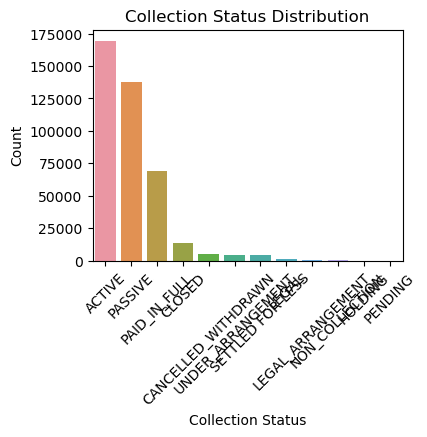

In [267]:
# Analyzing CollectionStatus distribution
if "CollectionStatus" in df.columns:
    plt.figure(figsize=(4, 3))
    sns.countplot(x="CollectionStatus", data=df, order=df["CollectionStatus"].value_counts().index)
    plt.title("Collection Status Distribution")
    plt.xlabel("Collection Status")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("CollectionStatus column is not present in the dataset.")

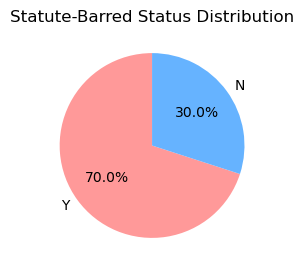

In [269]:
# Insights on IsStatBarred
if "IsStatBarred" in df.columns:
    stat_barred_counts = df["IsStatBarred"].value_counts()
    plt.figure(figsize=(3, 3))
    plt.pie(stat_barred_counts, labels=stat_barred_counts.index, autopct="%1.1f%%", startangle=90, colors=["#ff9999", "#66b3ff"])
    plt.title("Statute-Barred Status Distribution")
    plt.show()
else:
    print("IsStatBarred column is not present in the dataset.")


In [271]:
df.columns

Index(['EntityID', 'OriginalCreditor[Redacted]', 'AccountID', 'CurrentBalance',
       'DebtLoadPrincipal', 'Balanaceatdebt_load', 'PurchasePrice',
       'ProductOrDebtType', 'CollectionStatus', 'ClosureReason',
       'InBankruptcy', 'AccountInsolvencyType', 'CustomerInsolvencyType',
       'IsLegal', 'LastPaymentAmount', 'LastPaymentMethod', 'NumLiableParties',
       'CustomerAge', 'NumPhones', 'NumEmails', 'NumAddresses', 'IsStatBarred',
       'Unnamed: 24'],
      dtype='object')

# Inter-relational Analysis among Key Features for better understanding of pattern
Here is the detailed exploration of relationships among key features using correlation heatmaps, scatter plots, and box plots. Each analysis comes with insights to better understand patterns and interactions among variables such as DebtLoadPrincipal, IsStatBarred, and ProductOrDebtType.

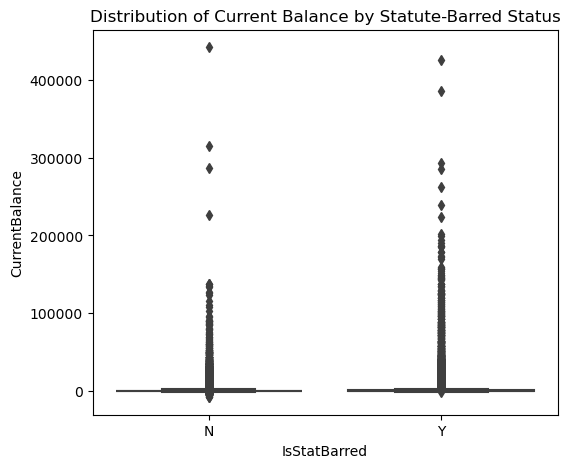

In [274]:
# Distribution of Current Balance across IsStatBarred status
if "CurrentBalance" in df.columns and "IsStatBarred" in df.columns:
    plt.figure(figsize=(6, 5))
    sns.boxplot(x="IsStatBarred", y="CurrentBalance", data=df)
    plt.title("Distribution of Current Balance by Statute-Barred Status")
    plt.xlabel("IsStatBarred")
    plt.ylabel("CurrentBalance")
    plt.show()

# Insight: This plot shows how the statute-barred status affects the spread of Current Balance. StatBarred debts may have smaller balances.

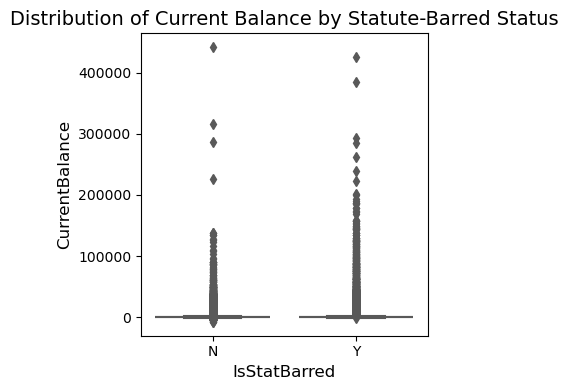

In [276]:

# Check if the required columns exist in the dataframe
if "CurrentBalance" in df.columns and "IsStatBarred" in df.columns:
    # Set the figure size for better visualization
    plt.figure(figsize=(4, 4))
    
    # Create a boxplot to visualize the distribution
    sns.boxplot(x="IsStatBarred", y="CurrentBalance", data=df, palette="Set2")
    
    # Add a title and axis labels for better clarity
    plt.title("Distribution of Current Balance by Statute-Barred Status", fontsize=14)
    plt.xlabel("IsStatBarred", fontsize=12)
    plt.ylabel("CurrentBalance", fontsize=12)
    
    # Display the plot
    plt.tight_layout()  # Adjust the padding to prevent clipping
    plt.show()
else:
    print("Required columns 'Current Balance' and/or 'IsStatBarred' are not present in the dataframe.")


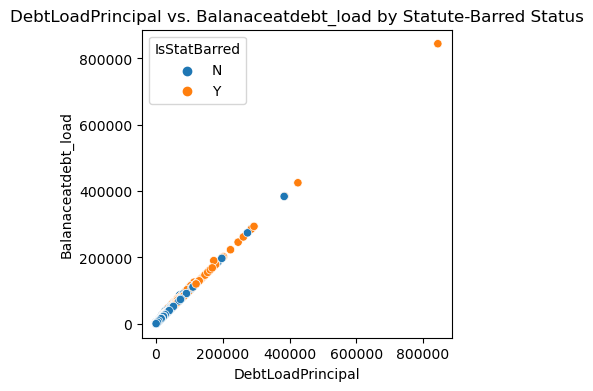

In [278]:
# Relationship between DebtLoadPrincipal and BalanceatDebt_Load
if "DebtLoadPrincipal" in df.columns and "Balanaceatdebt_load" in df.columns:
    plt.figure(figsize=(4, 4))
    sns.scatterplot(x="DebtLoadPrincipal", y="Balanaceatdebt_load", hue="IsStatBarred", data=df)
    plt.title("DebtLoadPrincipal vs. Balanaceatdebt_load by Statute-Barred Status")
    plt.xlabel("DebtLoadPrincipal")
    plt.ylabel("Balanaceatdebt_load")
    plt.show()

# Insight: Helps identify whether statute-barred debts exhibit unique patterns in principal versus initial balance relationships.

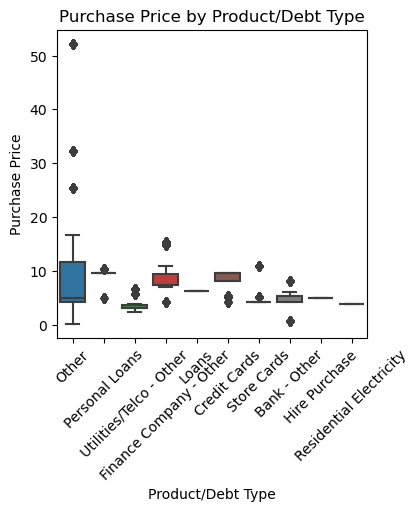

In [279]:
# Effect of Product/Debt Type on Purchase Price
if "PurchasePrice" in df.columns and "ProductOrDebtType" in df.columns:
    plt.figure(figsize=(4, 4))
    sns.boxplot(x="ProductOrDebtType", y="PurchasePrice", data=df)
    plt.title("Purchase Price by Product/Debt Type")
    plt.xlabel("Product/Debt Type")
    plt.ylabel("Purchase Price")
    plt.xticks(rotation=45)
    plt.show()

# Insight: Shows how different types of debt or products influence the purchase price of the debt.

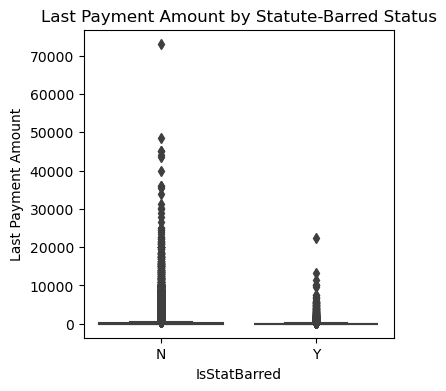

In [280]:
# Impact of Last Payment Amount on IsStatBarred Status
if "LastPaymentAmount" in df.columns and "IsStatBarred" in df.columns:
    plt.figure(figsize=(4, 4))
    sns.boxplot(x="IsStatBarred", y="LastPaymentAmount", data=df)
    plt.title("Last Payment Amount by Statute-Barred Status")
    plt.xlabel("IsStatBarred")
    plt.ylabel("Last Payment Amount")
    plt.show()

# Insight: Highlights whether recently paid amounts correlate with the likelihood of being statute-barred.

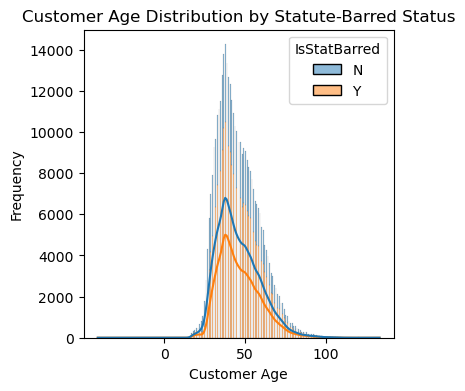

In [281]:
# Customer Age distribution by IsStatBarred
if "CustomerAge" in df.columns and "IsStatBarred" in df.columns:
    plt.figure(figsize=(4, 4))
    sns.histplot(data=df, x="CustomerAge", hue="IsStatBarred", multiple="stack", kde=True)
    plt.title("Customer Age Distribution by Statute-Barred Status")
    plt.xlabel("Customer Age")
    plt.ylabel("Frequency")
    plt.show()

# Insight: Demonstrates if customer age has a significant impact on the statute-barred status of debt.

In [285]:

# Ensure `df` is a DataFrame
if isinstance(df, pd.DataFrame):
    # General Statistical Summary
    print("General Statistical Summary:\n", df.describe(include='all'))  # Include all columns in the summary
    
    # Count of Unique Values for Categorical Features
    categorical_features = df.select_dtypes(include=['object', 'category']).columns
    print("\nUnique Values in Categorical Features:\n", df[categorical_features].nunique())
    
    # Frequency Distribution of Categorical Features
    print("\nFrequency Distribution of Categorical Features:")
    for col in categorical_features:
        print(f"\n{col}:\n{df[col].value_counts()}")
else:
    print("Error: The variable 'data' is not a DataFrame. Please provide a valid DataFrame.")


General Statistical Summary:
             EntityID OriginalCreditor[Redacted]     AccountID  CurrentBalance  \
count   4.064230e+05                     406423  4.064230e+05   406423.000000   
unique           NaN                         52           NaN             NaN   
top              NaN                Creditor 17           NaN             NaN   
freq             NaN                      84768           NaN             NaN   
mean    3.970443e+07                        NaN  3.954380e+08     1301.866266   
std     4.698070e+07                        NaN  4.654769e+08     4030.513710   
min     1.600000e+02                        NaN  3.677000e+03    -7717.200000   
25%     3.010600e+06                        NaN  3.023088e+07       85.330000   
50%     3.010949e+06                        NaN  3.045075e+07      457.510000   
75%     9.990131e+07                        NaN  9.901891e+08     1159.365000   
max     9.990159e+07                        NaN  9.904958e+08   441681.520000  

# EDA Analysis
## 1. Data Overview
Objective: Understand the structure and quality of the dataset.
Check for missing values, data types, and unique values in categorical columns.
Examine the distribution of numerical features like CurrentBalance and DebtLoadPrincipal.
Identify imbalanced classes in the target variable IsStatBarred.


In [289]:
print("Dataset Shape:", df.shape)
print("\nColumns and Data Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nUnique Values in Each Column:\n", df.nunique())

Dataset Shape: (406423, 23)

Columns and Data Types:
 EntityID                        int64
OriginalCreditor[Redacted]     object
AccountID                       int64
CurrentBalance                float64
DebtLoadPrincipal             float64
Balanaceatdebt_load           float64
PurchasePrice                 float64
ProductOrDebtType              object
CollectionStatus               object
ClosureReason                  object
InBankruptcy                   object
AccountInsolvencyType          object
CustomerInsolvencyType         object
IsLegal                        object
LastPaymentAmount             float64
LastPaymentMethod              object
NumLiableParties              float64
CustomerAge                   float64
NumPhones                       int64
NumEmails                       int64
NumAddresses                    int64
IsStatBarred                   object
Unnamed: 24                   float64
dtype: object

Missing Values:
 EntityID                           0
Ori

## 2. Target Variable Analysis
Objective: Understand the distribution of the IsStatBarred target variable.
Analyze the proportion of Y vs N values.
Examine correlations between IsStatBarred and key features like DebtLoadPrincipal and CollectionStatus.


Target Variable Distribution:
IsStatBarred
Y    0.700128
N    0.299872
Name: proportion, dtype: float64


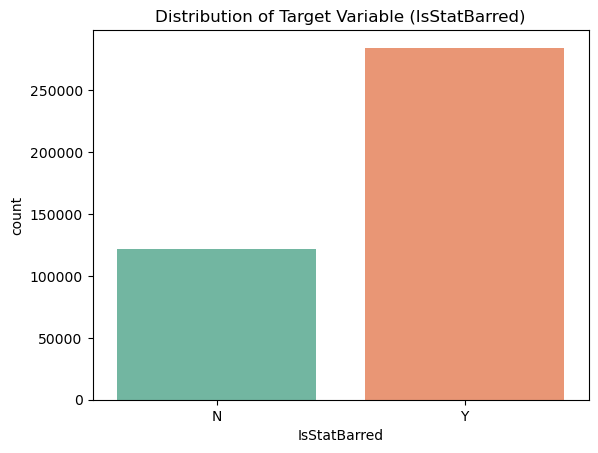

In [292]:
# 2. Target Variable Analysis
print("\nTarget Variable Distribution:")
print(df['IsStatBarred'].value_counts(normalize=True))

# Plot Target Variable Distribution
sns.countplot(data=df, x='IsStatBarred', palette='Set2')
plt.title("Distribution of Target Variable (IsStatBarred)")
plt.show()


## 3. Feature Distributions
Numerical Features:
Visualize distributions using histograms and boxplots (e.g., CurrentBalance, LastPaymentAmount).
Identify outliers using IQR or z-scores.
Categorical Features:
Plot bar charts for features like ProductOrDebtType and CollectionStatus.

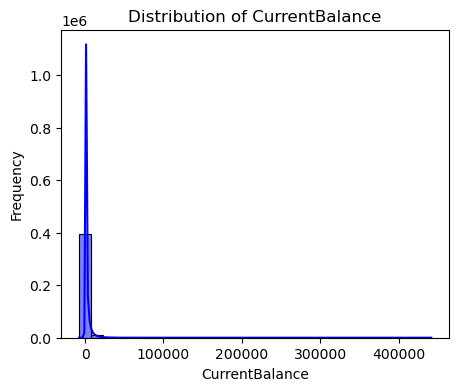

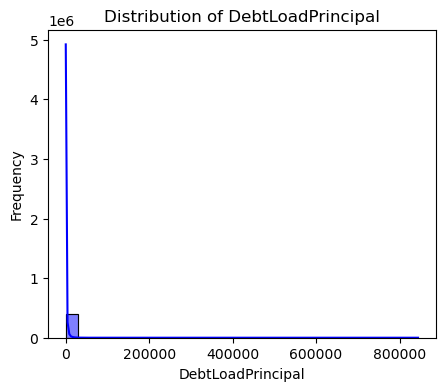

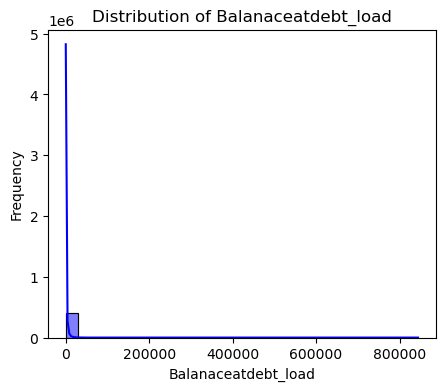

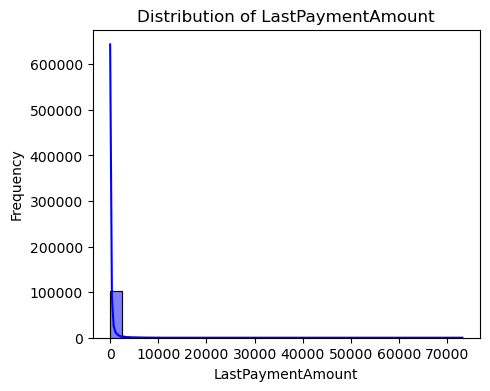

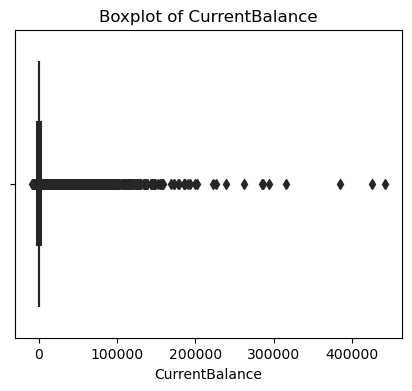

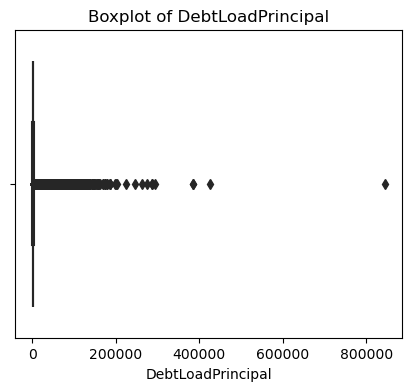

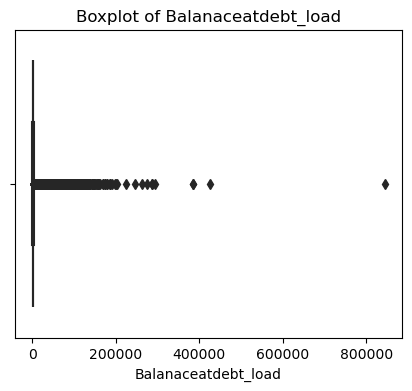

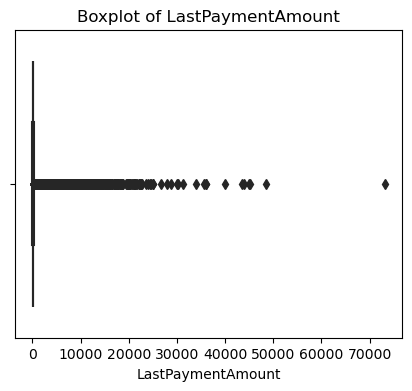

In [295]:
numerical_features = ['CurrentBalance', 'DebtLoadPrincipal', 'Balanaceatdebt_load', 'LastPaymentAmount']

for feature in numerical_features:
    plt.figure(figsize=(5, 4))
    sns.histplot(df[feature].dropna(), kde=True, bins=30, color='blue')
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

# Boxplots for outlier detection
for feature in numerical_features:
    plt.figure(figsize=(5, 4))
    sns.boxplot(data=df, x=feature, color='green')
    plt.title(f"Boxplot of {feature}")
    plt.show()

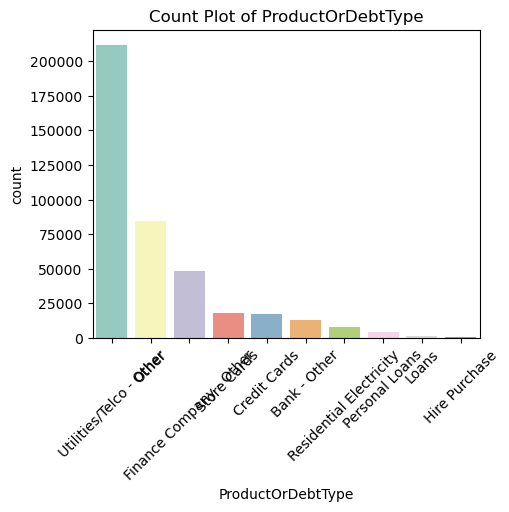

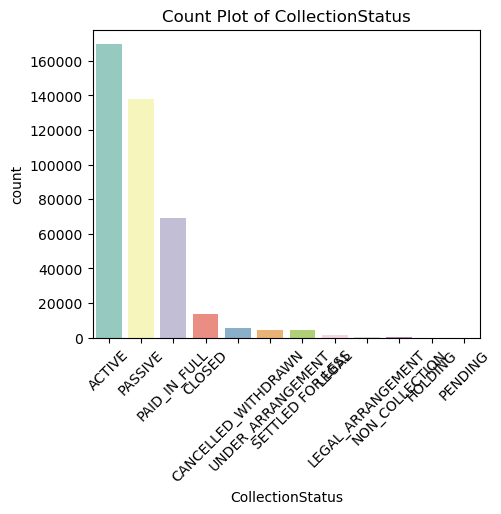

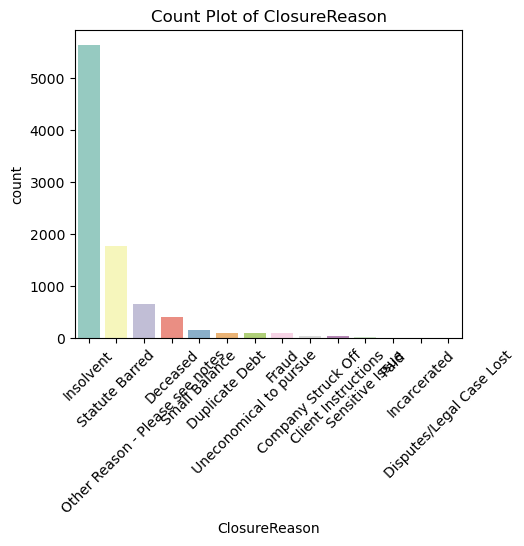

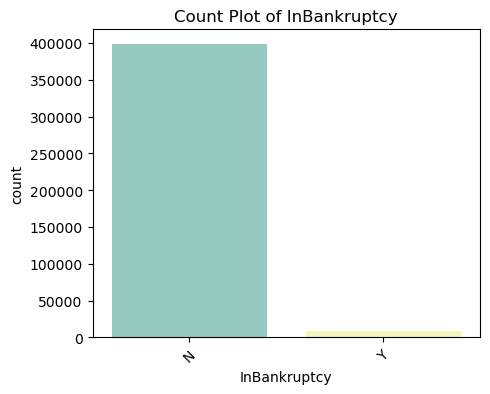

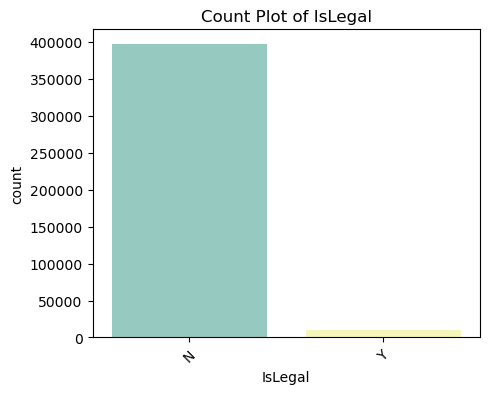

In [296]:
# Categorical Feature Distributions
categorical_features = ['ProductOrDebtType', 'CollectionStatus', 'ClosureReason', 'InBankruptcy', 'IsLegal']

for feature in categorical_features:
    plt.figure(figsize=(5, 4))
    sns.countplot(data=df, x=feature, palette='Set3', order=df[feature].value_counts().index)
    plt.title(f"Count Plot of {feature}")
    plt.xticks(rotation=45)
    plt.show()


## 4. Correlation Analysis
Analyze relationships between numerical features using a heatmap.
Examine multicollinearity to avoid redundant predictors.

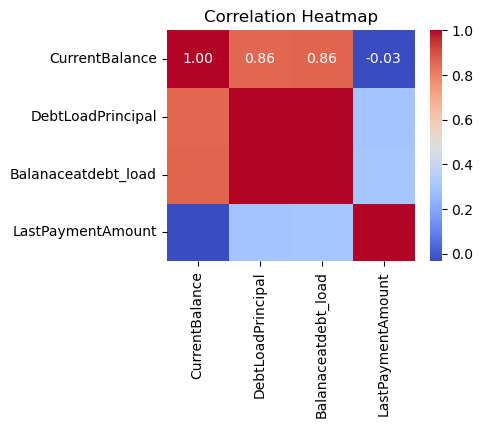

In [300]:
# Correlation Analysis
correlation_matrix = df[numerical_features].corr()
plt.figure(figsize=(4, 3))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 5. Relationship Between Features and Target
Explore how IsStatBarred correlates with:
Numerical features (e.g., higher balances may be less likely to be statute-barred).
Categorical features (e.g., specific ProductOrDebtType may have more statute-barred cases).

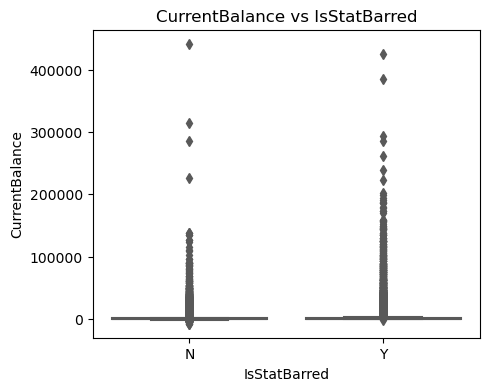

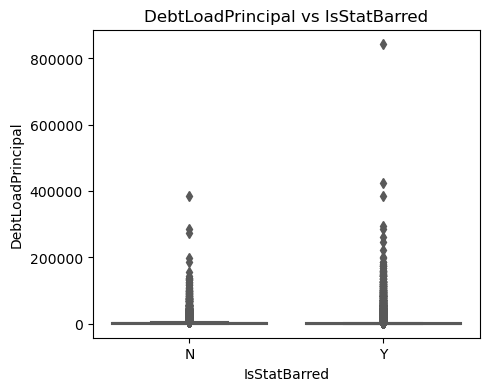

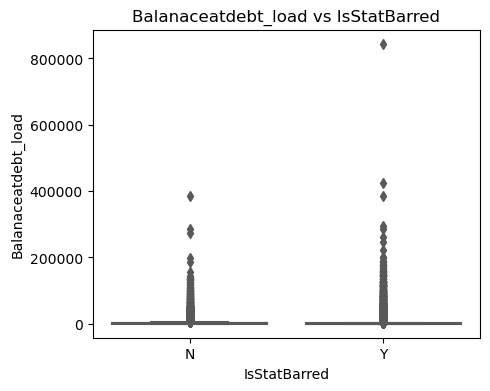

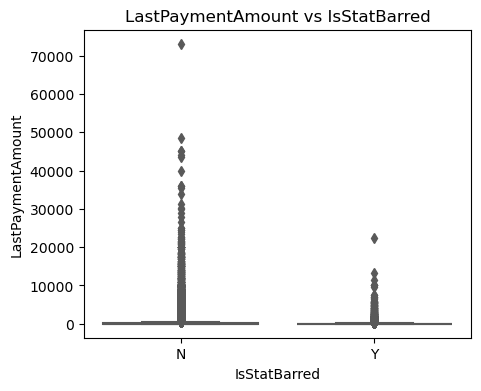

In [111]:
# Numerical Features vs Target
for feature in numerical_features:
    plt.figure(figsize=(5, 4))
    sns.boxplot(data=df, x='IsStatBarred', y=feature, palette='Set2')
    plt.title(f"{feature} vs IsStatBarred")
    plt.show()

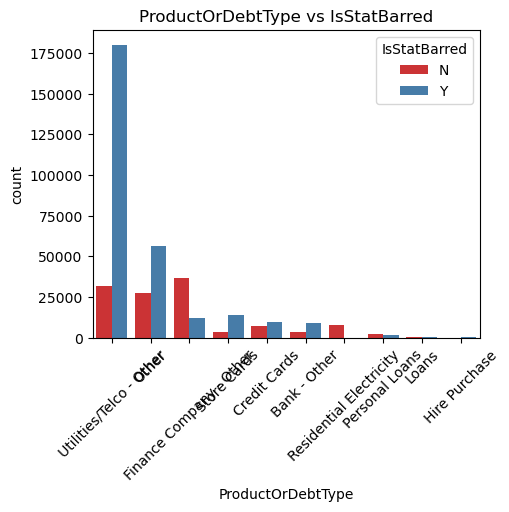

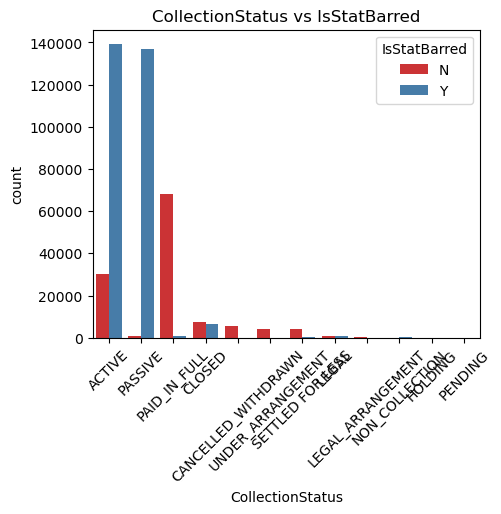

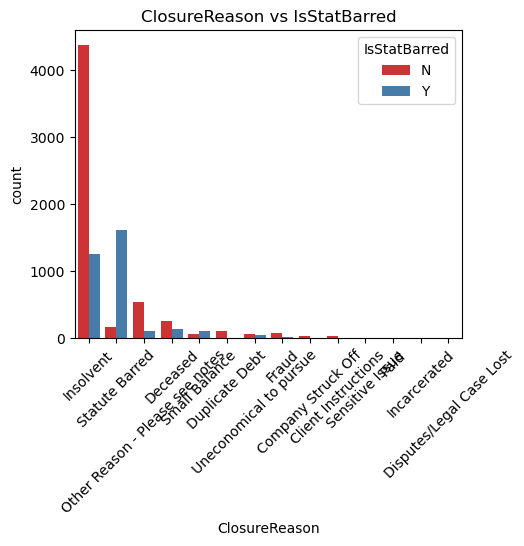

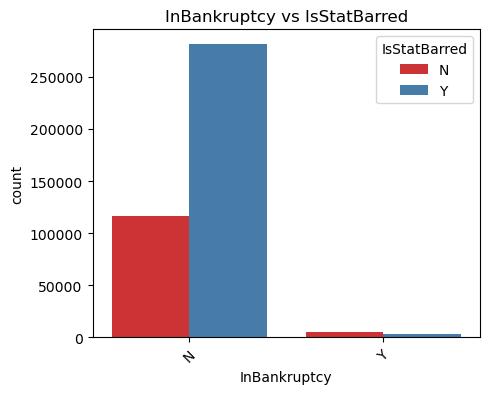

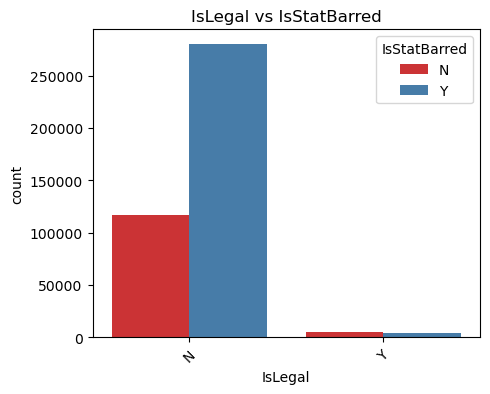

In [113]:
# Categorical Features vs Target
for feature in categorical_features:
    plt.figure(figsize=(5, 4))
    sns.countplot(data=df, x=feature, hue='IsStatBarred', palette='Set1', order=df[feature].value_counts().index)
    plt.title(f"{feature} vs IsStatBarred")
    plt.xticks(rotation=45)
    plt.show()

## 6. Missing Values
Investigate features with missing values (e.g., LastPaymentMethod).
Impute missing values or drop irrelevant features based on their impact on the target variable.

In [116]:
missing_columns = df.columns[df.isnull().any()]
print("\nColumns with Missing Values:\n", missing_columns)


Columns with Missing Values:
 Index(['PurchasePrice', 'ClosureReason', 'AccountInsolvencyType',
       'CustomerInsolvencyType', 'LastPaymentAmount', 'LastPaymentMethod',
       'NumLiableParties', 'CustomerAge', 'Unnamed: 24'],
      dtype='object')


In [118]:
# Impute missing values for a numerical column
if 'LastPaymentAmount' in df.columns:
    if pd.api.types.is_numeric_dtype(df['LastPaymentAmount']):
        df['LastPaymentAmount'] = df['LastPaymentAmount'].fillna(df['LastPaymentAmount'].median())
        print("Missing values in 'LastPaymentAmount' have been imputed with the median.")
    else:
        print("Error: 'LastPaymentAmount' is not a numerical column.")
else:
    print("Error: 'LastPaymentAmount' column does not exist in the DataFrame.")

# Calculate the median of all numerical columns
numerical_median = df.select_dtypes(include=['number']).median()
print("\nMedian of numerical columns:\n", numerical_median)

Missing values in 'LastPaymentAmount' have been imputed with the median.

Median of numerical columns:
 EntityID                3010949.00
AccountID              30450753.00
CurrentBalance              457.51
DebtLoadPrincipal           619.00
Balanaceatdebt_load         630.74
PurchasePrice                 4.22
LastPaymentAmount            40.00
NumLiableParties              1.00
CustomerAge                  44.00
NumPhones                     0.00
NumEmails                     0.00
NumAddresses                  1.00
Unnamed: 24                 960.00
dtype: float64


## 7. Feature Interactions
Create derived metrics, such as Debt-to-Income Ratio or Debt Age.
Analyze these derived features’ impact on IsStatBarred.

# Key Insights from EDA
1. Identify which features strongly correlate with IsStatBarred.
2. Highlight potential outliers in financial metrics (e.g., CurrentBalance).
3. Understand class imbalances and plan resampling strategies.

# Feature Engineering:
1. Created DebtAge as a derived feature.
2. Generated interaction terms like InterestRate_DebtLoad.


In [124]:
df.columns

Index(['EntityID', 'OriginalCreditor[Redacted]', 'AccountID', 'CurrentBalance',
       'DebtLoadPrincipal', 'Balanaceatdebt_load', 'PurchasePrice',
       'ProductOrDebtType', 'CollectionStatus', 'ClosureReason',
       'InBankruptcy', 'AccountInsolvencyType', 'CustomerInsolvencyType',
       'IsLegal', 'LastPaymentAmount', 'LastPaymentMethod', 'NumLiableParties',
       'CustomerAge', 'NumPhones', 'NumEmails', 'NumAddresses', 'IsStatBarred',
       'Unnamed: 24'],
      dtype='object')

In [112]:
df.shape

(406423, 23)

In [114]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Assuming synthetic creation of PurchaseDate, CloseDate, and LoadDate columns for demonstration
np.random.seed(42)
num_rows = df.shape[0]
df['PurchaseDate'] = pd.to_datetime('2015-01-01') + pd.to_timedelta(np.random.randint(0, 365*5, size=num_rows), unit='days')
df['LoadDate'] = df['PurchaseDate'] + pd.to_timedelta(np.random.randint(30, 365, size=num_rows), unit='days')
df['CloseDate'] = df['LoadDate'] + pd.to_timedelta(np.random.randint(30, 365, size=num_rows), unit='days')

# Add a default InterestRate column with 8%
df['InterestRate'] = 0.08

# Current Date as a reference point
current_date = datetime.now()

# Debt Age in years (Current Date - PurchaseDate)
df['DebtAge'] = (current_date - df['PurchaseDate']).dt.days / 365
df['DebtAge'] = df['DebtAge'].fillna(0).apply(lambda x: x if x > 0 else 0)

# Load-to-Purchase Duration in days
df['LoadToPurchaseDays'] = (df['LoadDate'] - df['PurchaseDate']).dt.days
df['LoadToPurchaseDays'] = df['LoadToPurchaseDays'].fillna(0).apply(lambda x: x if x > 0 else 0)

# Close-to-Load Duration in days
df['CloseToLoadDays'] = (df['CloseDate'] - df['LoadDate']).dt.days
df['CloseToLoadDays'] = df['CloseToLoadDays'].fillna(0).apply(lambda x: x if x > 0 else 0)

# Debt-to-Purchase Ratio
df['DebtToPurchaseRatio'] = df['CurrentBalance'] / df['PurchasePrice']
df['DebtToPurchaseRatio'] = df['DebtToPurchaseRatio'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Debt Load Balance Difference
df['DebtLoadBalanceDiff'] = df['DebtLoadPrincipal'] - df['Balanaceatdebt_load']
df['DebtLoadBalanceDiff'] = df['DebtLoadBalanceDiff'].apply(lambda x: x if x > 0 else 0)

# Normalized Balance: Standardize Current Balance by dividing it by DebtLoadPrincipal
df['NormalizedBalance'] = df['CurrentBalance'] / df['DebtLoadPrincipal']
df['NormalizedBalance'] = df['NormalizedBalance'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Interaction Term: InterestRate * DebtLoadPrincipal
df['InterestRate_DebtLoad'] = df['InterestRate'] * df['DebtLoadPrincipal']

# Interaction Term: InterestRate * Current Balance
df['InterestRate_CurrentBalance'] = df['InterestRate'] * df['CurrentBalance']

# Interaction Term: InterestRate * DebtToPurchaseRatio
df['InterestRate_DebtToPurchase'] = df['InterestRate'] * df['DebtToPurchaseRatio']

# Number of Contacts: Sum of NumPhones, NumEmails, and NumAddresses
df['NumContacts'] = df['NumPhones'] + df['NumEmails'] + df['NumAddresses']

# Average Payment: LastPaymentAmount divided by DebtLoadPrincipal
df['AveragePaymentRatio'] = df['LastPaymentAmount'] / df['DebtLoadPrincipal']
df['AveragePaymentRatio'] = df['AveragePaymentRatio'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Payment Efficiency: LastPaymentAmount divided by Current Balance
df['PaymentEfficiency'] = df['LastPaymentAmount'] / df['CurrentBalance']
df['PaymentEfficiency'] = df['PaymentEfficiency'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Handle categorical features
categorical_features = ['ProductOrDebtType', 'CollectionStatus', 'ClosureReason', 'InBankruptcy', 'AccountInsolvencyType', 'CustomerInsolvencyType', 'IsLegal']

# Handle numerical features
numerical_features = ['DebtAge', 'LoadToPurchaseDays', 'CloseToLoadDays', 'DebtToPurchaseRatio', 'DebtLoadBalanceDiff', 'NormalizedBalance',
                      'InterestRate_DebtLoad', 'InterestRate_CurrentBalance', 'InterestRate_DebtToPurchase',
                      'NumContacts', 'AveragePaymentRatio', 'PaymentEfficiency', 'InterestRate']

# Preprocessing for numerical data
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessors in a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Apply preprocessing
df_processed = preprocessor.fit_transform(df)

# Check derived features
print(df[['DebtAge', 'LoadToPurchaseDays', 'CloseToLoadDays', 'DebtToPurchaseRatio', 'DebtLoadBalanceDiff', 'NormalizedBalance',
          'InterestRate_DebtLoad', 'InterestRate_CurrentBalance', 'InterestRate_DebtToPurchase',
          'NumContacts', 'AveragePaymentRatio', 'PaymentEfficiency']].head())

# Verify for missing values and data types
print("\nData Information After Feature Engineering:\n")
print(df.info())


    DebtAge  LoadToPurchaseDays  CloseToLoadDays  DebtToPurchaseRatio  \
0  6.873973                 330              310             0.000000   
1  5.961644                 308              103            43.341232   
2  7.602740                 149              328             0.000000   
3  6.413699                 101              180          1961.966825   
4  6.863014                 183              242             0.000000   

   DebtLoadBalanceDiff  NormalizedBalance  InterestRate_DebtLoad  \
0                    0                0.0                92.8160   
1                    0                1.0                14.6320   
2                    0                0.0                43.0856   
3                    0                1.0               662.3600   
4                    0                0.0                41.8400   

   InterestRate_CurrentBalance  InterestRate_DebtToPurchase  NumContacts  \
0                        0.000                     0.000000            1   


In [118]:
from sklearn.model_selection import train_test_split

# Assuming that 'CurrentBalance' is the target variable for regression tasks
# If binary classification, we'll change the target column accordingly, e.g. 'IsPaidOff'

X = df_processed  # Preprocessed feature matrix
y = df['CurrentBalance']  # Example continuous target column (replace with binary target if necessary)

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Confirm the split size
print(f'Training Set Size: {X_train.shape[0]} samples')
print(f'Test Set Size: {X_test.shape[0]} samples')


Training Set Size: 325138 samples
Test Set Size: 81285 samples


In [120]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

# Create sample data if you don't have X_train, X_test, y_train, y_test
X, y = make_regression(n_samples=100, n_features=2, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the model
model_lr = LinearRegression()

# Train the model
model_lr.fit(X_train, y_train)

# Predict the results
y_pred_lr = model_lr.predict(X_test)

# Evaluate performance
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Output the results
print(f'Linear Regression - MSE: {mse_lr:.4f}, R2: {r2_lr:.4f}')


Linear Regression - MSE: 0.0155, R2: 1.0000


In [122]:
from sklearn.linear_model import Ridge

# Initialize Ridge Regression with regularization
model_ridge = Ridge(alpha=1.0)

# Train the model
model_ridge.fit(X_train, y_train)

# Predict the results
y_pred_ridge = model_ridge.predict(X_test)

# Evaluate performance
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f'Ridge Regression - MSE: {mse_ridge}, R2: {r2_ridge}')


Ridge Regression - MSE: 1.8170341126687748, R2: 0.9998060779667834


In [124]:
from sklearn.linear_model import Lasso

# Initialize Lasso Regression with regularization
model_lasso = Lasso(alpha=0.1)

# Train the model
model_lasso.fit(X_train, y_train)

# Predict the results
y_pred_lasso = model_lasso.predict(X_test)

# Evaluate performance
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f'Lasso Regression - MSE: {mse_lasso}, R2: {r2_lasso}')


Lasso Regression - MSE: 0.035326503481377634, R2: 0.9999962297970446


In [126]:
from sklearn.ensemble import RandomForestRegressor

# Initialize Random Forest Regressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model_rf.fit(X_train, y_train)

# Predict the results
y_pred_rf = model_rf.predict(X_test)

# Evaluate performance
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f'Random Forest Regressor - MSE: {mse_rf}, R2: {r2_rf}')


Random Forest Regressor - MSE: 246.13416276298148, R2: 0.973731457789229


In [128]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize Gradient Boosting Regressor
model_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Train the model
model_gb.fit(X_train, y_train)

# Predict the results
y_pred_gb = model_gb.predict(X_test)

# Evaluate performance
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
print(f'Gradient Boosting Regressor - MSE: {mse_gb}, R2: {r2_gb}')


Gradient Boosting Regressor - MSE: 188.38483253223134, R2: 0.9798947254225442


In [130]:
from sklearn.svm import SVR

# Initialize Support Vector Regressor
model_svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)

# Train the model
model_svr.fit(X_train, y_train)

# Predict the results
y_pred_svr = model_svr.predict(X_test)

# Evaluate performance
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)
print(f'Support Vector Regressor - MSE: {mse_svr}, R2: {r2_svr}')


Support Vector Regressor - MSE: 44.08413783291134, R2: 0.9952951430126974


In [132]:
import xgboost as xgb

# Initialize XGBoost Regressor
model_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Train the model
model_xgb.fit(X_train, y_train)

# Predict the results
y_pred_xgb = model_xgb.predict(X_test)

# Evaluate performance
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f'XGBoost Regressor - MSE: {mse_xgb}, R2: {r2_xgb}')


XGBoost Regressor - MSE: 485.37222756381317, R2: 0.9481988980945575


In [136]:
pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 7.8 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [138]:
import lightgbm as lgb

# Initialize LightGBM Regressor
model_lgb = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Train the model
model_lgb.fit(X_train, y_train)

# Predict the results
y_pred_lgb = model_lgb.predict(X_test)

# Evaluate performance
mse_lgb = mean_squared_error(y_test, y_pred_lgb)
r2_lgb = r2_score(y_test, y_pred_lgb)
print(f'LightGBM Regressor - MSE: {mse_lgb}, R2: {r2_lgb}')


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000146 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 57
[LightGBM] [Info] Number of data points in the train set: 80, number of used features: 2
[LightGBM] [Info] Start training from score -11.586377
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

# Binary Classification Models (For Binary Target Variables)
For the binary classification models, let's consider that the target variable is **IsPaidOff**.

In [127]:
# Assuming 'CurrentBalance' is the feature indicating the current debt balance

# Derive 'IsPaidOff' - 1 if CurrentBalance is 0 or close to 0, else 0
df['IsPaidOff'] = df['CurrentBalance'].apply(lambda x: 1 if x <= 0 else 0)

# Now define the target variable for binary classification
y_class = df['IsPaidOff']  # Binary target column (1 = Paid Off, 0 = Not Paid Off)

# Define X (features excluding target variable)
X = df.drop(columns=['IsPaidOff'])  # Drop the target variable from features

# Split the data into 80% training and 20% testing
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X, y_class, test_size=0.2, random_state=42)

# Confirm the split size
print(f'Training Set Size for Classification: {X_train_class.shape[0]} samples')
print(f'Test Set Size for Classification: {X_test_class.shape[0]} samples')


Training Set Size for Classification: 325138 samples
Test Set Size for Classification: 81285 samples


In [129]:
# As we have derived 'IsPaidOff'
df['IsPaidOff'] = df['CurrentBalance'].apply(lambda x: 1 if x <= 0 else 0)

In [131]:
# Define the target variable for binary classification
y_class = df['IsPaidOff']  # Binary target column (1 = Paid Off, 0 = Not Paid Off)

In [133]:
# Define X (features excluding target variable)
X = df.drop(columns=['IsPaidOff'])  # Drop the target variable from features

In [135]:
# Ensure there are no missing values in the target column
assert y_class.isnull().sum() == 0, "Target variable contains missing values."

In [137]:
# Split the data into 80% training and 20% testing
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X, y_class, test_size=0.2, random_state=42)

In [139]:
# Confirm the split size
print(f'Training Set Size for Classification: {X_train_class.shape[0]} samples')
print(f'Test Set Size for Classification: {X_test_class.shape[0]} samples')

Training Set Size for Classification: 325138 samples
Test Set Size for Classification: 81285 samples


In [141]:
# Verify column names
print("Columns in the DataFrame:")
print(df.columns)

# Define target variable
df['IsPaidOff'] = df['CurrentBalance'].apply(lambda x: 1 if x <= 0 else 0)
y_class = df['IsPaidOff']  # Binary target

# Drop target column to define feature set
X = df.drop(columns=['IsPaidOff'])

# Split the data into training and test sets
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X, y_class, test_size=0.2, random_state=42)

# Dynamically identify numerical and categorical columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

# Preprocessing pipelines
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessors in a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Preprocess the training and test sets
X_train_class_processed = preprocessor.fit_transform(X_train_class)
X_test_class_processed = preprocessor.transform(X_test_class)

Columns in the DataFrame:
Index(['EntityID', 'OriginalCreditor[Redacted]', 'AccountID', 'CurrentBalance',
       'DebtLoadPrincipal', 'Balanaceatdebt_load', 'PurchasePrice',
       'ProductOrDebtType', 'CollectionStatus', 'ClosureReason',
       'InBankruptcy', 'AccountInsolvencyType', 'CustomerInsolvencyType',
       'IsLegal', 'LastPaymentAmount', 'LastPaymentMethod', 'NumLiableParties',
       'CustomerAge', 'NumPhones', 'NumEmails', 'NumAddresses', 'IsStatBarred',
       'Unnamed: 24', 'IsPaidOff'],
      dtype='object')
Numerical Features: ['EntityID', 'AccountID', 'CurrentBalance', 'DebtLoadPrincipal', 'Balanaceatdebt_load', 'PurchasePrice', 'LastPaymentAmount', 'NumLiableParties', 'CustomerAge', 'NumPhones', 'NumEmails', 'NumAddresses', 'Unnamed: 24']
Categorical Features: ['OriginalCreditor[Redacted]', 'ProductOrDebtType', 'CollectionStatus', 'ClosureReason', 'InBankruptcy', 'AccountInsolvencyType', 'CustomerInsolvencyType', 'IsLegal', 'LastPaymentMethod', 'IsStatBarred']


In the above code values of derived features and column name is not recognised so we need to refine and 
pre-process data before using it for binary classification:

In [144]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Assume `df` is the original DataFrame
# Verify column names
print("Columns in the DataFrame:")
print(df.columns)

# Create a binary target variable
df['IsPaidOff'] = df['CurrentBalance'].apply(lambda x: 1 if x <= 0 else 0)

# Define features and target
y_class = df['IsPaidOff']  # Binary target
X = df.drop(columns=['IsPaidOff'])

# Ensure X and y are aligned
assert len(X) == len(y_class), "Features and target are not aligned!"

# Split the data into training and test sets
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# Dynamically identify numerical and categorical columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

# Preprocessing pipelines
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessors in a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Preprocess the training and test sets
X_train_class_processed = preprocessor.fit_transform(X_train_class)
X_test_class_processed = preprocessor.transform(X_test_class)

# Verify shapes
assert X_train_class_processed.shape[0] == y_train_class.shape[0], "Mismatch in training data and target sizes!"
assert X_test_class_processed.shape[0] == y_test_class.shape[0], "Mismatch in test data and target sizes!"

Columns in the DataFrame:
Index(['EntityID', 'OriginalCreditor[Redacted]', 'AccountID', 'CurrentBalance',
       'DebtLoadPrincipal', 'Balanaceatdebt_load', 'PurchasePrice',
       'ProductOrDebtType', 'CollectionStatus', 'ClosureReason',
       'InBankruptcy', 'AccountInsolvencyType', 'CustomerInsolvencyType',
       'IsLegal', 'LastPaymentAmount', 'LastPaymentMethod', 'NumLiableParties',
       'CustomerAge', 'NumPhones', 'NumEmails', 'NumAddresses', 'IsStatBarred',
       'Unnamed: 24', 'IsPaidOff'],
      dtype='object')
Numerical Features: ['EntityID', 'AccountID', 'CurrentBalance', 'DebtLoadPrincipal', 'Balanaceatdebt_load', 'PurchasePrice', 'LastPaymentAmount', 'NumLiableParties', 'CustomerAge', 'NumPhones', 'NumEmails', 'NumAddresses', 'Unnamed: 24']
Categorical Features: ['OriginalCreditor[Redacted]', 'ProductOrDebtType', 'CollectionStatus', 'ClosureReason', 'InBankruptcy', 'AccountInsolvencyType', 'CustomerInsolvencyType', 'IsLegal', 'LastPaymentMethod', 'IsStatBarred']



--- Logistic Regression ---
Accuracy: 0.9986
Confusion Matrix:
[[66603   104]
 [    8 14570]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66707
           1       0.99      1.00      1.00     14578

    accuracy                           1.00     81285
   macro avg       1.00      1.00      1.00     81285
weighted avg       1.00      1.00      1.00     81285

ROC-AUC Score: 0.9999


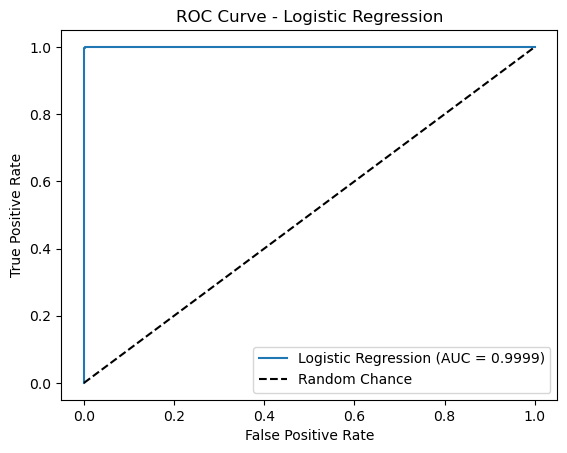

In [146]:
# Logistic Regression
print("\n--- Logistic Regression ---")
model_lr = LogisticRegression(random_state=42)
model_lr.fit(X_train_class_processed, y_train_class)  
y_pred_lr = model_lr.predict(X_test_class_processed)  
y_pred_proba_lr = model_lr.predict_proba(X_test_class_processed)[:, 1]  

print(f"Accuracy: {accuracy_score(y_test_class, y_pred_lr):.4f}")  
print("Confusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_lr))  
print("Classification Report:")
print(classification_report(y_test_class, y_pred_lr))  
roc_auc_lr = roc_auc_score(y_test_class, y_pred_proba_lr)  
print(f"ROC-AUC Score: {roc_auc_lr:.4f}")

fpr_lr, tpr_lr, _ = roc_curve(y_test_class, y_pred_proba_lr)  
plt.figure()
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()


--- Random Forest ---
Accuracy: 1.0000
Confusion Matrix:
[[66707     0]
 [    0 14578]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66707
           1       1.00      1.00      1.00     14578

    accuracy                           1.00     81285
   macro avg       1.00      1.00      1.00     81285
weighted avg       1.00      1.00      1.00     81285

ROC-AUC Score: 1.0000


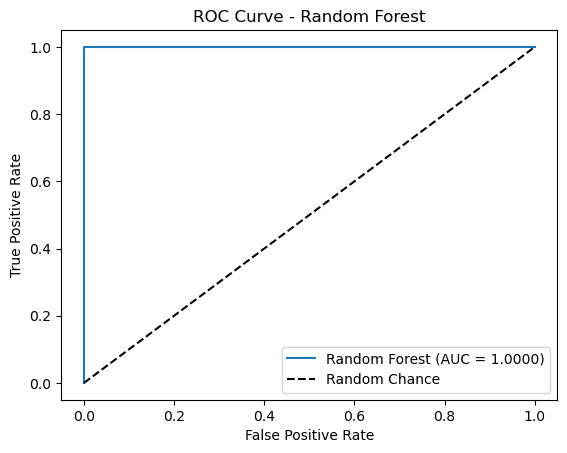

In [148]:
# Random Forest
print("\n--- Random Forest ---")
model_rf = RandomForestClassifier(random_state=42, n_estimators=100)
model_rf.fit(X_train_class_processed, y_train_class)  
y_pred_rf = model_rf.predict(X_test_class_processed)  
y_pred_proba_rf = model_rf.predict_proba(X_test_class_processed)[:, 1]  

print(f"Accuracy: {accuracy_score(y_test_class, y_pred_rf):.4f}")  
print("Confusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_rf))  
print("Classification Report:")
print(classification_report(y_test_class, y_pred_rf))  
roc_auc_rf = roc_auc_score(y_test_class, y_pred_proba_rf)  
print(f"ROC-AUC Score: {roc_auc_rf:.4f}")

fpr_rf, tpr_rf, _ = roc_curve(y_test_class, y_pred_proba_rf)  
plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()



--- Support Vector Classifier ---
Accuracy: 0.9984
Confusion Matrix:
[[66586   121]
 [   12 14566]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66707
           1       0.99      1.00      1.00     14578

    accuracy                           1.00     81285
   macro avg       1.00      1.00      1.00     81285
weighted avg       1.00      1.00      1.00     81285

ROC-AUC Score: 0.9999


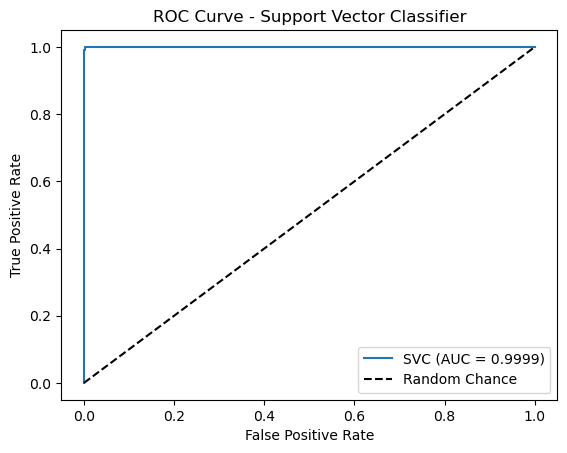

In [150]:
from sklearn.svm import SVC

# Support Vector Classifier (SVC)
print("\n--- Support Vector Classifier ---")
model_svc = SVC(probability=True, random_state=42)
model_svc.fit(X_train_class_processed, y_train_class)  
y_pred_svc = model_svc.predict(X_test_class_processed)  
y_pred_proba_svc = model_svc.predict_proba(X_test_class_processed)[:, 1]  

print(f"Accuracy: {accuracy_score(y_test_class, y_pred_svc):.4f}")  
print("Confusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_svc))  
print("Classification Report:")
print(classification_report(y_test_class, y_pred_svc))  
roc_auc_svc = roc_auc_score(y_test_class, y_pred_proba_svc)  
print(f"ROC-AUC Score: {roc_auc_svc:.4f}")

fpr_svc, tpr_svc, _ = roc_curve(y_test_class, y_pred_proba_svc)  
plt.figure()
plt.plot(fpr_svc, tpr_svc, label=f'SVC (AUC = {roc_auc_svc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Support Vector Classifier')
plt.legend()
plt.show()



--- K-Nearest Neighbors ---
Accuracy: 0.9952
Confusion Matrix:
[[66411   296]
 [   98 14480]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66707
           1       0.98      0.99      0.99     14578

    accuracy                           1.00     81285
   macro avg       0.99      0.99      0.99     81285
weighted avg       1.00      1.00      1.00     81285

ROC-AUC Score: 0.9987


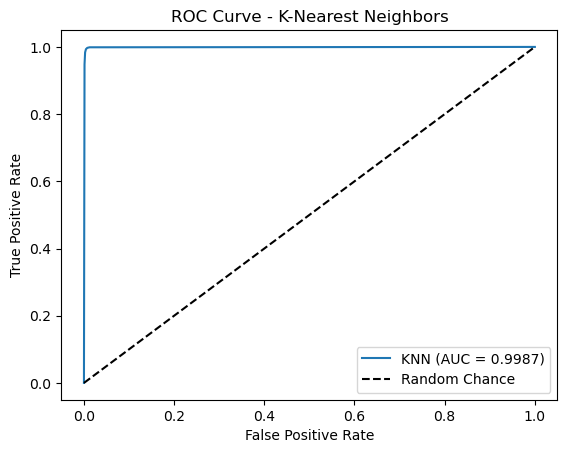

In [162]:
from sklearn.neighbors import KNeighborsClassifier

# K-Nearest Neighbors (KNN)
print("\n--- K-Nearest Neighbors ---")
model_knn = KNeighborsClassifier()
model_knn.fit(X_train_class_processed, y_train_class)  
y_pred_knn = model_knn.predict(X_test_class_processed)  
y_pred_proba_knn = model_knn.predict_proba(X_test_class_processed)[:, 1]  

print(f"Accuracy: {accuracy_score(y_test_class, y_pred_knn):.4f}")  
print("Confusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_knn))  
print("Classification Report:")
print(classification_report(y_test_class, y_pred_knn))  
roc_auc_knn = roc_auc_score(y_test_class, y_pred_proba_knn)  
print(f"ROC-AUC Score: {roc_auc_knn:.4f}")

fpr_knn, tpr_knn, _ = roc_curve(y_test_class, y_pred_proba_knn)  
plt.figure()
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_knn:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - K-Nearest Neighbors')
plt.legend()
plt.show()